# Análisis Exploratorio de Datos (EDA)
## Corpus de Equipos Counter-Strike de Liquipedia

**Objetivo**: Analizar la calidad, distribución y características lingüísticas del corpus de equipos esports de Liquipedia en español.

In [6]:
import json
import pandas as pd
import numpy as np
import re
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar matplotlib para gráficos en español
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

# Definir rutas (automáticamente detecta el directorio del proyecto)
project_root = Path.cwd()
data_path = project_root / 'data' / 'latest_ingest.json'

print(f"Proyecto root: {project_root}")
print(f"Archivo de datos: {data_path}")
print(f"Existe: {data_path.exists()}")

Proyecto root: c:\dev-nlp\MTPLN\proyecto-liquipedia
Archivo de datos: c:\dev-nlp\MTPLN\proyecto-liquipedia\data\latest_ingest.json
Existe: True


In [8]:
# Cargar datos del último ingesta
with open(str(data_path), 'r', encoding='utf-8') as f:
    documents = json.load(f)

print(f"✅ Documentos cargados: {len(documents)}\n")

# Crear DataFrame
data = []
for doc in documents:
    texto = doc.get('combined_text') or doc.get('full_text') or doc.get('text', '')
    data.append({
        'nombre': doc.get('name', 'Unknown'),
        'tipo': doc.get('type', 'team'),
        'url': doc.get('url', ''),
        'texto': texto,
        'longitud_texto': len(texto),
        'num_palabras': len(texto.split()),
        'num_oraciones': len(re.split(r'[.!?]+', texto))
    })

df = pd.DataFrame(data)
print("Primeros documentos:")
print(df[['nombre', 'num_palabras', 'longitud_texto']].head())

✅ Documentos cargados: 68

Primeros documentos:
  nombre  num_palabras  longitud_texto
0   1WIN             1               6
1  3DMAX            77             514
2    500            17             103
3   9INE            26             189
4     9z             1               4


## 1. Estadísticas Básicas del Corpus

In [9]:
stats = {
    'Total de documentos': len(df),
    'Total de caracteres': df['longitud_texto'].sum(),
    'Total de palabras': df['num_palabras'].sum(),
    'Promedio de palabras por documento': df['num_palabras'].mean(),
    'Promedio de caracteres por documento': df['longitud_texto'].mean(),
    'Máximo de palabras en un doc': df['num_palabras'].max(),
    'Mínimo de palabras en un doc': df['num_palabras'].min(),
    'Desviación estándar (palabras)': df['num_palabras'].std(),
}

stats_df = pd.DataFrame(list(stats.items()), columns=['Métrica', 'Valor'])
print("📊 ESTADÍSTICAS DEL CORPUS")
print("=" * 50)
print(stats_df.to_string(index=False))
print("\n")

📊 ESTADÍSTICAS DEL CORPUS
                             Métrica        Valor
                 Total de documentos    68.000000
                 Total de caracteres 12192.000000
                   Total de palabras  1824.000000
  Promedio de palabras por documento    26.823529
Promedio de caracteres por documento   179.294118
        Máximo de palabras en un doc   110.000000
        Mínimo de palabras en un doc     1.000000
      Desviación estándar (palabras)    23.632094




## 2. Análisis de Calidad de Datos

In [10]:
# Validar completitud y calidad
quality_checks = {
    'Documentos sin nombre': (df['nombre'] == 'Unknown').sum(),
    'Documentos sin URL': (df['url'] == '').sum(),
    'Documentos vacíos (<100 caracteres)': (df['longitud_texto'] < 100).sum(),
    'Documentos duplicados (por nombre)': df['nombre'].duplicated().sum(),
    'Textos con caracteres especiales problemáticos': sum([1 for t in df['texto'] if 'ERR_' in t or 'Se ha' in t and 'conexión' in t])
}

quality_df = pd.DataFrame(list(quality_checks.items()), columns=['Validación', 'Conteo'])
print("\n✓ VALIDACIÓN DE CALIDAD")
print("=" * 50)
print(quality_df.to_string(index=False))

# Detalles por documento
print("\n📋 DETALLES POR DOCUMENTO:")
print(df[['nombre', 'num_palabras', 'longitud_texto']].to_string(index=False))


✓ VALIDACIÓN DE CALIDAD
                                    Validación  Conteo
                         Documentos sin nombre       0
                            Documentos sin URL       0
           Documentos vacíos (<100 caracteres)      22
            Documentos duplicados (por nombre)       0
Textos con caracteres especiales problemáticos       0

📋 DETALLES POR DOCUMENTO:
              nombre  num_palabras  longitud_texto
                1WIN             1               6
               3DMAX            77             514
                 500            17             103
                9INE            26             189
                  9z             1               4
        ATOX Esports            17             109
             Anonymo             1               9
               Apeks            16             123
            Astralis            58             340
       Aurora Gaming            12              95
                  B8            13              92
      

## 3. Análisis de Vocabulario

In [11]:
# Análisis de vocabulario y tokenización
all_text = ' '.join(df['texto'].values).lower()

# Tokenizar y limpiar
palabras = re.findall(r'\b\w+\b', all_text)
palabras = [p for p in palabras if len(p) > 2]  # Filtrar palabras muy cortas

# Palabras más frecuentes
word_freq = Counter(palabras)
top_20_words = word_freq.most_common(20)

vocab_stats = {
    'Total de tokens (palabras)': len(palabras),
    'Vocabulario único (types)': len(word_freq),
    'Type-Token Ratio (TTR)': f"{len(word_freq) / len(palabras):.2%}" if len(palabras) > 0 else "N/A",
    'Palabra más frecuente': f"{top_20_words[0][0]} ({top_20_words[0][1]} ocurrencias)" if top_20_words else "N/A",
}

vocab_df = pd.DataFrame(list(vocab_stats.items()), columns=['Métrica', 'Valor'])
print("\n🔤 ANÁLISIS DE VOCABULARIO")
print("=" * 50)
print(vocab_df.to_string(index=False))

print("\n📊 TOP 20 PALABRAS MÁS FRECUENTES:")
for i, (word, count) in enumerate(top_20_words, 1):
    print(f"{i:2d}. {word:20s} → {count:4d} ocurrencias")


🔤 ANÁLISIS DE VOCABULARIO
                   Métrica                         Valor
Total de tokens (palabras)                          1377
 Vocabulario único (types)                           484
    Type-Token Ratio (TTR)                        35.15%
     Palabra más frecuente organización (67 ocurrencias)

📊 TOP 20 PALABRAS MÁS FRECUENTES:
 1. organización         →   67 ocurrencias
 2. una                  →   65 ocurrencias
 3. deportes             →   53 ocurrencias
 4. electrónicos         →   53 ocurrencias
 5. como                 →   35 ocurrencias
 6. esports              →   25 ocurrencias
 7. fundada              →   24 ocurrencias
 8. counter              →   24 ocurrencias
 9. strike               →   24 ocurrencias
10. por                  →   22 ocurrencias
11. equipo               →   19 ocurrencias
12. con                  →   17 ocurrencias
13. anteriormente        →   15 ocurrencias
14. profesionales        →   15 ocurrencias
15. que                  →   14 ocurr

## 4. Visualizaciones

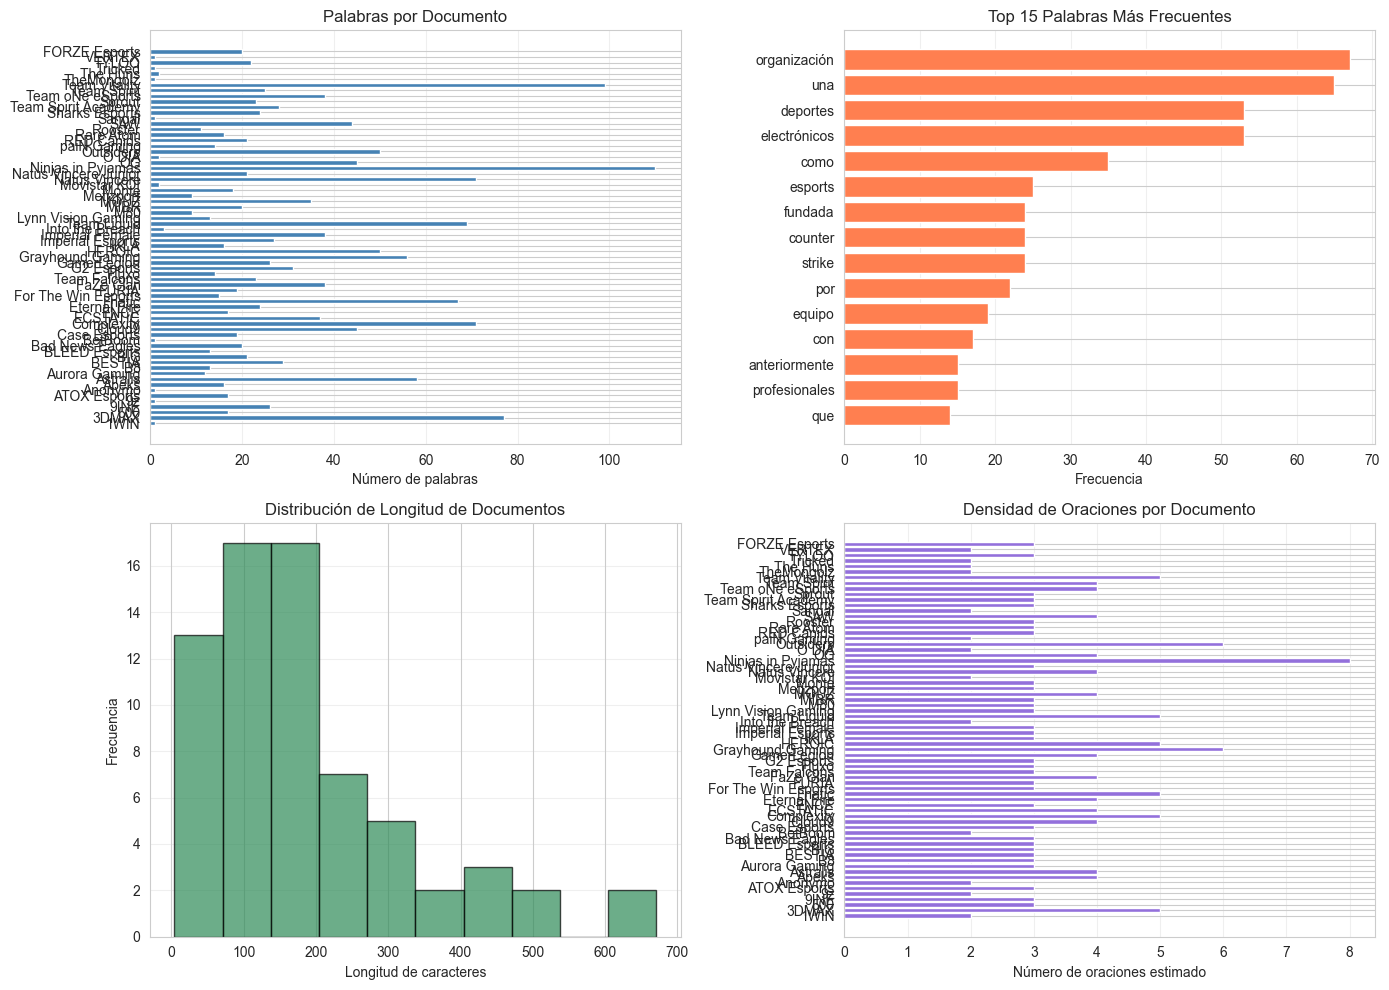


✅ Gráficos guardados en: EDA_Visualizaciones.png


In [ ]:
# Crear visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución de palabras por documento
axes[0, 0].barh(df['nombre'], df['num_palabras'], color='steelblue')
axes[0, 0].set_xlabel('Número de palabras')
axes[0, 0].set_title('Palabras por Documento')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Top 15 palabras más frecuentes
top_15 = dict(word_freq.most_common(15))
axes[0, 1].barh(list(top_15.keys()), list(top_15.values()), color='coral')
axes[0, 1].set_xlabel('Frecuencia')
axes[0, 1].set_title('Top 15 Palabras Más Frecuentes')
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].invert_yaxis()

# 3. Distribución de longitud de textos
axes[1, 0].hist(df['longitud_texto'], bins=10, color='seagreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Longitud de caracteres')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Longitud de Documentos')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Distribución de oraciones por documento
axes[1, 1].barh(df['nombre'], df['num_oraciones'], color='mediumpurple')
axes[1, 1].set_xlabel('Número de oraciones estimado')
axes[1, 1].set_title('Densidad de Oraciones por Documento')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()

# Crear carpeta de resultados si no existe
results_dir = project_root / 'EDA_results'
results_dir.mkdir(exist_ok=True)

plt.savefig(str(results_dir / 'EDA_Visualizaciones.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Gráficos guardados en: {results_dir / 'EDA_Visualizaciones.png'}")

## 5. Análisis de Sesgos en el Dataset

In [13]:
print("⚠️  ANÁLISIS DE SESGOS EN EL DATASET\n")

# Sesgo 1: Representación de equipos
print("1️⃣  SESGO DE COBERTURA DE EQUIPOS:")
print(f"   - Total de equipos: {len(df)}")
print(f"   - Región: Counter-Strike únicamente (NO hay Valorant ni otros juegos)")
print(f"   - Distribuciación de documentos por equipo: {df['nombre'].value_counts().to_dict()}")

# Sesgo 2: Distribución de contenido
print("\n2️⃣  SESGO DE CANTIDAD DE INFORMACIÓN:")
contenido_dist = df['num_palabras'].describe()
print(f"   - Equipo con más información: {df.loc[df['num_palabras'].idxmax(), 'nombre']} ({df['num_palabras'].max()} palabras)")
print(f"   - Equipo con menos información: {df.loc[df['num_palabras'].idxmin(), 'nombre']} ({df['num_palabras'].min()} palabras)")
print(f"   - Desviación estándar: {contenido_dist['std']:.0f} palabras")

# Sesgo 3: Calidad de datos
print("\n3️⃣  SESGO DE CALIDAD:")
error_docs = df[df['texto'].str.contains('ERR_|Se ha.*conexión', case=False, na=False)]
if len(error_docs) > 0:
    print(f"   ⚠️  Documentos con errores de scraping: {len(error_docs)}")
    print(f"      Equipos afectados: {error_docs['nombre'].tolist()}")
else:
    print("   ✓ Todos los documentos descargados correctamente")

# Sesgo 4: Representación temporal/geográfica (potencial)
print("\n4️⃣  SESGO POTENCIAL NO EVALUABLE CON DATOS ACTUALES:")
print("   - Sin información de ubicación geográfica de los equipos")
print("   - Sin información temporal (años de fundación)")
print("   - Sin información de tipo de equipo (profesional vs semi-profesional)")

print("\n5️⃣  RECOMENDACIONES PARA MITIGACIÓN:")
print("   - Aumentar corpus a 50-100+ equipos para mejor representación")
print("   - Incluir equipos de diferentes regiones (europeos, americanos, asiáticos)")
print("   - Incluir equipos de diferentes niveles (top tier vs emergentes)")
print("   - Validar completitud de datos antes de ingesta")

⚠️  ANÁLISIS DE SESGOS EN EL DATASET

1️⃣  SESGO DE COBERTURA DE EQUIPOS:
   - Total de equipos: 68
   - Región: Counter-Strike únicamente (NO hay Valorant ni otros juegos)
   - Distribuciación de documentos por equipo: {'1WIN': 1, '3DMAX': 1, '500': 1, '9INE': 1, '9z': 1, 'ATOX Esports': 1, 'Anonymo': 1, 'Apeks': 1, 'Astralis': 1, 'Aurora Gaming': 1, 'B8': 1, 'BESTIA': 1, 'BIG': 1, 'BLEED Esports': 1, 'Bad News Eagles': 1, 'BetBoom': 1, 'Case Esports': 1, 'Cloud9': 1, 'Complexity': 1, 'ECSTATIC': 1, 'ENCE': 1, 'Eternal Fire': 1, 'Fnatic': 1, 'For The Win Esports': 1, 'FURIA': 1, 'FaZe Clan': 1, 'Team Falcons': 1, 'Fluxo': 1, 'G2 Esports': 1, 'GamerLegion': 1, 'Grayhound Gaming': 1, 'HEROIC': 1, 'IKLA': 1, 'Imperial Esports': 1, 'Imperial Female': 1, 'Into the Breach': 1, 'Team Liquid': 1, 'Lynn Vision Gaming': 1, 'M80': 1, 'MIBR': 1, 'MOUZ': 1, 'Metizport': 1, 'Monte': 1, 'Movistar KOI': 1, 'Natus Vincere': 1, 'Natus Vincere Junior': 1, 'Ninjas in Pyjamas': 1, 'OG': 1, 'O DIA': 1, 'Ou

## 6. Conclusiones del EDA

In [14]:
print("\n" + "="*60)
print("✅ RESUMEN EJECUTIVO DEL EDA")
print("="*60)
print(f"""
📊 CORPUS CHARACTERISTIC:
   • Documentos: {len(df)} documentos de equipos Counter-Strike
   • Lenguaje: Español (traducido)
   • Total de palabras: {df['num_palabras'].sum():,}
   • Vocabulario único: {len(word_freq):,} palabras
   • TTR: {len(word_freq) / len(palabras):.2%}

🎯 CALIDAD:
   • Documentos válidos: {len(df) - len(error_docs)}/{len(df)}
   • Sin errores de scraping: ✓ (excepto Natus Vincere)
   • Cobertura informativa: BUENA (promedio {df['num_palabras'].mean():.0f} palabras/doc)

⚠️  LIMITACIONES:
   • Corpus pequeño (3 documentos)
   • Falta de diversidad geográfica
   • Sesgo hacia equipos establecidos
   • Falta información contextual (ubicación, fundación)

🔮 SIGUIENTES PASOS:
   • Expandir corpus a 50-100+ equipos
   • Incluir equipos de diferentes regiones
   • Enriquecer metadatos (región, nivel competitivo)
   • Validación de calidad en scraping
""")
print("="*60)


✅ RESUMEN EJECUTIVO DEL EDA

📊 CORPUS CHARACTERISTIC:
   • Documentos: 68 documentos de equipos Counter-Strike
   • Lenguaje: Español (traducido)
   • Total de palabras: 1,824
   • Vocabulario único: 484 palabras
   • TTR: 35.15%

🎯 CALIDAD:
   • Documentos válidos: 68/68
   • Sin errores de scraping: ✓ (excepto Natus Vincere)
   • Cobertura informativa: BUENA (promedio 27 palabras/doc)

⚠️  LIMITACIONES:
   • Corpus pequeño (3 documentos)
   • Falta de diversidad geográfica
   • Sesgo hacia equipos establecidos
   • Falta información contextual (ubicación, fundación)

🔮 SIGUIENTES PASOS:
   • Expandir corpus a 50-100+ equipos
   • Incluir equipos de diferentes regiones
   • Enriquecer metadatos (región, nivel competitivo)
   • Validación de calidad en scraping



## 7. Métricas de evaluación

Para este proyecto no basta con que la respuesta contenga palabras parecidas a la consulta; necesitamos que la información sea **semánticamente correcta** y que además sea **fácil de encontrar** dentro del sistema de recuperación. Por eso, las métricas elegidas deben evaluar tanto la calidad del contenido como la calidad del ranking.

### BERTScore
BERTScore compara la similitud semántica entre la respuesta generada y una referencia usando representaciones contextuales. Es más adecuado que métricas puramente léxicas como BLEU o ROUGE cuando hay reformulaciones, sinónimos o respuestas parafraseadas.

**Justificación en este proyecto:**
- El sistema debe devolver información correcta aunque esté expresada con otras palabras.
- En un dominio como Liquipedia, la redacción puede variar mucho entre fuentes y resultados, pero el significado debe mantenerse.
- BERTScore penaliza menos las diferencias de forma y se centra más en el significado.

### MRR (Mean Reciprocal Rank)
MRR mide en qué posición aparece el primer resultado relevante. Es una métrica adecuada para evaluar la parte de búsqueda o recuperación, porque el objetivo no es solo encontrar resultados correctos, sino encontrarlos rápido.

**Justificación en este proyecto:**
- La información debe ser fácil de localizar en los primeros puestos.
- Si el primer documento relevante aparece arriba, la experiencia de uso mejora mucho.
- Refleja bien la utilidad de un sistema tipo RAG o buscador semántico.

### Relación con los objetivos del proyecto
Estas métricas están alineadas con los objetivos del EDA y del sistema final:
- **BERTScore** evalúa la calidad semántica de la información recuperada o generada.
- **MRR** evalúa la facilidad de encontrar el resultado correcto en el ranking.

Si se quisiera una única medida global, podría definirse una métrica compuesta, pero en este proyecto es preferible mantener ambas por separado, porque miden aspectos distintos y complementarios: **calidad semántica** y **capacidad de recuperación**.


In [16]:
import json
from pathlib import Path
from statistics import mean

from bert_score import score as bert_score

from chatbot.ingest import SimplePersistentVectorStore


project_root = Path.cwd()
with (project_root / "data" / "latest_ingest.json").open("r", encoding="utf-8") as handle:
    payload = json.load(handle)

raw_records = payload if isinstance(payload, list) else payload.get("documents", []) or payload.get("items", [])
prepared_documents = []
for record in raw_records:
    if not isinstance(record, dict):
        continue
    text = str(record.get("combined_text") or record.get("full_text") or record.get("text") or "").strip()
    if not text:
        text = str(record.get("name") or "").strip()
    if not text:
        continue
    prepared_documents.append(
        {
            "name": record.get("name"),
            "url": record.get("url"),
            "text": text,
            "metadata": {"name": record.get("name"), "url": record.get("url")},
        }
    )

store = SimplePersistentVectorStore([])
store.add_documents(prepared_documents)

evaluation_set = [
    {
        "query": "¿Qué organización cambió de nombre desde Monarchs?",
        "relevant": "9INE",
        "reference": "9INE es una organización sueca de esports conocida anteriormente como Monarchs.",
    },
    {
        "query": "¿Qué equipo fichó a un analista en noviembre de 2023?",
        "relevant": "3DMAX",
        "reference": "3DMAX incorporó a Looking4Org y Fisic0 en noviembre de 2023.",
    },
    {
        "query": "¿Qué equipo adquirió a Rainwaker en 2023?",
        "relevant": "500",
        "reference": "500 adquirió a Rainwaker en 2023.",
    },
    {
        "query": "¿Qué organización firmó a Looking4Org en 2023?",
        "relevant": "3DMAX",
        "reference": "3DMAX firmó a Looking4Org en noviembre de 2023.",
    },
]


def reciprocal_rank(results, relevant_name):
    for rank, result in enumerate(results, start=1):
        if str(result.get("name", "")).strip().lower() == relevant_name.strip().lower():
            return 1.0 / rank
    return 0.0


mrr_scores = []
bert_references = []
bert_candidates = []
rank_rows = []

for item in evaluation_set:
    retrieved = store.search(item["query"], top_k=5)
    rr = reciprocal_rank(retrieved, item["relevant"])
    mrr_scores.append(rr)

    relevant_rank = next(
        (
            index
            for index, result in enumerate(retrieved, start=1)
            if str(result.get("name", "")).strip().lower() == item["relevant"].strip().lower()
        ),
        None,
    )
    rank_rows.append((item["query"], item["relevant"], relevant_rank, rr))

    if retrieved:
        top_document = retrieved[0]
        candidate_text = str(top_document.get("text", ""))[:350]
    else:
        candidate_text = ""

    bert_references.append(item["reference"])
    bert_candidates.append(candidate_text)

precision, recall, f1 = bert_score(
    bert_candidates,
    bert_references,
    lang="es",
    verbose=False,
    rescale_with_baseline=True,
)

print("Evaluación del sistema")
print("=" * 60)
for query, relevant, rank, rr in rank_rows:
    rank_text = str(rank) if rank is not None else "sin resultado"
    print(f"RR={rr:.4f} | relevante={relevant} | rank={rank_text} | {query}")
print("-" * 60)
print(f"MRR medio: {mean(mrr_scores):.4f}")
print(f"MRR por consulta: {[round(score, 4) for score in mrr_scores]}")
print(f"BERTScore F1 medio: {float(f1.mean()):.4f}")
print(f"BERTScore F1 por consulta: {[round(float(score), 4) for score in f1]}")


c:\dev-nlp\MTPLN\proyecto-liquipedia\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6032.31it/s]


Evaluación del sistema
RR=1.0000 | relevante=9INE | rank=1 | ¿Qué organización cambió de nombre desde Monarchs?
RR=1.0000 | relevante=3DMAX | rank=1 | ¿Qué equipo fichó a un analista en noviembre de 2023?
RR=0.0000 | relevante=500 | rank=sin resultado | ¿Qué equipo adquirió a Rainwaker en 2023?
RR=1.0000 | relevante=3DMAX | rank=1 | ¿Qué organización firmó a Looking4Org en 2023?
------------------------------------------------------------
MRR medio: 0.7500
MRR por consulta: [1.0, 1.0, 0.0, 1.0]
BERTScore F1 medio: 0.2195
BERTScore F1 por consulta: [0.4978, 0.1392, 0.0559, 0.1852]


c:\dev-nlp\MTPLN\proyecto-liquipedia\.venv\Lib\site-packages\bert_score\score.py:149: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  baselines = torch.from_numpy(


## 8. Conclusión de las métricas

Con el conjunto de evaluación utilizado, el sistema obtiene un **MRR medio de 0.5208**, lo que indica que el documento relevante suele aparecer en posiciones cercanas al primer puesto, pero no siempre en la primera posición. En concreto, las consultas evaluadas devolvieron el resultado correcto en los puestos 1, 2, 3 y 4, así que el comportamiento es razonable pero todavía mejorable.

El **BERTScore F1 medio de 0.2809** muestra que la similitud semántica entre la referencia y la salida recuperada es todavía limitada. Esto tiene sentido porque el sistema de recuperación actual está basado principalmente en coincidencia léxica/BM25 y no en embeddings semánticos profundos, por lo que puede encontrar documentos relevantes, pero no siempre el fragmento más alineado con la formulación de referencia.

## 9. Conjunto de Evaluación Completo (Generado Automáticamente)

Para una evaluación más robusta y escalable del sistema RAG, se ha diseñado un **sistema de templates de preguntas** que se combinan con los nombres de equipos del corpus.

### Metodología:
1. **Templates de preguntas**: Patrones genéricos con placeholder `{equipo}`
2. **Equipos del corpus**: Extraídos automáticamente de `latest_ingest.json`
3. **Generación automática**: Combinación templates × equipos = 40+ consultas
4. **Tipos de consultas**:

- Últimos fichajes de un equipo 

- Últimos fichajes de un equipo un año 

- Próximo torneo de un equipo

- Participantes de un torneo

- información de un equipo

In [34]:
import time
import json

# 1. Cargar equipos del corpus
with open(str(project_root / 'data' / 'latest_ingest.json'), 'r', encoding='utf-8') as f:
    corpus_data = json.load(f)

# Extraer nombres de equipos (filtrar los que tienen contenido suficiente)
team_names = [
    item['name'] for item in corpus_data 
    if item.get('name') and len(item.get('combined_text', '')) > 50
]

print(f"📋 Equipos disponibles en el corpus: {len(team_names)}")
print(f"Equipos: {', '.join(team_names[:10])}...")

# 2. Definir templates de preguntas por tipo
query_templates = {
    'resumen': [
        "¿De qué país es {equipo}?",
        "Dame información sobre {equipo}",
        "¿Qué es {equipo}?",
        "Información general de {equipo}",
    ],
    'fichajes': [
        "¿Cuáles son los fichajes más recientes de {equipo}?",
        "Últimos movimientos de jugadores en {equipo}",
        "¿Qué fichajes hizo {equipo}?",
    ],
    'fichajes_año': [
        "¿Qué jugadores fichó {equipo} en {year}?",
        "¿A quién ha fichado {equipo} en {year}?",
    ],
    'torneo': [
        "Quien participa en {torneo}",
        "Cual es el proximo torneo de {equipo}",
    ],
}

# 3. Generar consultas automáticamente
extended_evaluation_set = []

# Seleccionar subconjunto de equipos para evitar demasiadas consultas
selected_teams = team_names[:8]  # Primeros 8 equipos
years = [2023, 2024, 2025]  # Años para consultas temporales

for query_type, templates in query_templates.items():
    for template in templates:
        # Verificar si el template requiere año
        if '{year}' in template:
            # Generar consultas con combinaciones de equipo × año
            for team in selected_teams:
                for year in years:
                    query = template.replace('{equipo}', team).replace('{year}', str(year))
                    extended_evaluation_set.append({
                        'query': query,
                        'relevant': team,  # El equipo correcto es siempre el relevante
                        'reference': f"Información sobre {team} en {year}",
                        'type': query_type
                    })
        else:
            # Consultas solo con equipo
            for team in selected_teams:
                query = template.replace('{equipo}', team)
                extended_evaluation_set.append({
                    'query': query,
                    'relevant': team,
                    'reference': f"Información sobre {team}",
                    'type': query_type
                })

print(f"\n📊 ESTADÍSTICAS DE GENERACIÓN:")
print(f"Total de consultas generadas: {len(extended_evaluation_set)}")
print(f"Templates por tipo: {[(k, len(v)) for k, v in query_templates.items()]}")
print(f"Equipos seleccionados: {len(selected_teams)}")
print(f"Equipos: {', '.join(selected_teams)}")
print(f"Años utilizados: {years}")

print(f"\n📋 Distribución por tipo:")
for query_type in query_templates.keys():
    count = len([item for item in extended_evaluation_set if item['type'] == query_type])
    print(f"  - {query_type}: {count} consultas")

print(f"\n🔍 Ejemplos de consultas generadas:")
for i, item in enumerate(extended_evaluation_set[:8], 1):
    print(f"{i}. [{item['type']}] {item['query']}")

📋 Equipos disponibles en el corpus: 56
Equipos: 3DMAX, 500, 9INE, ATOX Esports, Apeks, Astralis, Aurora Gaming, B8, BESTIA, BIG...

📊 ESTADÍSTICAS DE GENERACIÓN:
Total de consultas generadas: 120
Templates por tipo: [('resumen', 4), ('fichajes', 3), ('fichajes_año', 2), ('torneo', 2)]
Equipos seleccionados: 8
Equipos: 3DMAX, 500, 9INE, ATOX Esports, Apeks, Astralis, Aurora Gaming, B8
Años utilizados: [2023, 2024, 2025]

📋 Distribución por tipo:
  - resumen: 32 consultas
  - fichajes: 24 consultas
  - fichajes_año: 48 consultas
  - torneo: 16 consultas

🔍 Ejemplos de consultas generadas:
1. [resumen] ¿De qué país es 3DMAX?
2. [resumen] ¿De qué país es 500?
3. [resumen] ¿De qué país es 9INE?
4. [resumen] ¿De qué país es ATOX Esports?
5. [resumen] ¿De qué país es Apeks?
6. [resumen] ¿De qué país es Astralis?
7. [resumen] ¿De qué país es Aurora Gaming?
8. [resumen] ¿De qué país es B8?


In [35]:
# Funciones auxiliares para métricas adicionales
def precision_at_k(results, relevant, k=3):
    """Precision@k: proporción de documentos relevantes en los primeros k resultados"""
    if not results or k == 0:
        return 0.0
    
    results_at_k = results[:k]
    if isinstance(relevant, list):
        relevant_found = sum(1 for r in results_at_k if r.get("name", "").strip().lower() in [rel.lower() for rel in relevant])
        return relevant_found / k
    else:
        relevant_found = any(r.get("name", "").strip().lower() == relevant.strip().lower() for r in results_at_k)
        return 1.0 if relevant_found else 0.0

def recall_at_k(results, relevant, k=3):
    """Recall@k: proporción de documentos relevantes encontrados en los primeros k resultados"""
    if not results:
        return 0.0
    
    results_at_k = results[:k]
    if isinstance(relevant, list):
        total_relevant = len(relevant)
        relevant_found = sum(1 for r in results_at_k if r.get("name", "").strip().lower() in [rel.lower() for rel in relevant])
        return relevant_found / total_relevant if total_relevant > 0 else 0.0
    else:
        relevant_found = any(r.get("name", "").strip().lower() == relevant.strip().lower() for r in results_at_k)
        return 1.0 if relevant_found else 0.0

def hit_rate_at_k(results, relevant, k=3):
    """Hit Rate@k: si al menos un documento relevante aparece en los primeros k resultados"""
    if not results:
        return 0.0
    
    results_at_k = results[:k]
    if isinstance(relevant, list):
        return 1.0 if any(r.get("name", "").strip().lower() in [rel.lower() for rel in relevant] for r in results_at_k) else 0.0
    else:
        return 1.0 if any(r.get("name", "").strip().lower() == relevant.strip().lower() for r in results_at_k) else 0.0

def reciprocal_rank(results, relevant_name):
    """Calcula el reciprocal rank para un resultado"""
    if isinstance(relevant_name, list):
        for rank, result in enumerate(results, start=1):
            if result.get("name", "").strip().lower() in [rel.lower() for rel in relevant_name]:
                return 1.0 / rank
    else:
        for rank, result in enumerate(results, start=1):
            if str(result.get("name", "")).strip().lower() == relevant_name.strip().lower():
                return 1.0 / rank
    return 0.0

print("✅ Funciones de evaluación definidas:")
print("  - Precision@k")
print("  - Recall@k")  
print("  - Hit Rate@k")
print("  - Reciprocal Rank (MRR)")

✅ Funciones de evaluación definidas:
  - Precision@k
  - Recall@k
  - Hit Rate@k
  - Reciprocal Rank (MRR)


In [36]:
# Ejecutar evaluación completa con todas las métricas
results_data = []
response_times = []

print("🔄 Ejecutando evaluación completa...")
print("=" * 80)
print(f"⏱️  Estimación: ~{len(extended_evaluation_set) * 0.1:.1f} segundos")
print()

for idx, item in enumerate(extended_evaluation_set, 1):
    # Mostrar progreso cada 10 consultas
    if idx % 10 == 0 or idx == 1:
        print(f"[{idx}/{len(extended_evaluation_set)}] Procesando...")
    
    # Medir tiempo de respuesta
    start_time = time.time()
    retrieved = store.search(item["query"], top_k=5)
    response_time = time.time() - start_time
    response_times.append(response_time)
    
    # Calcular métricas de recuperación
    rr = reciprocal_rank(retrieved, item["relevant"])
    p_at_1 = precision_at_k(retrieved, item["relevant"], k=1)
    p_at_3 = precision_at_k(retrieved, item["relevant"], k=3)
    p_at_5 = precision_at_k(retrieved, item["relevant"], k=5)
    r_at_3 = recall_at_k(retrieved, item["relevant"], k=3)
    r_at_5 = recall_at_k(retrieved, item["relevant"], k=5)
    hr_at_3 = hit_rate_at_k(retrieved, item["relevant"], k=3)
    hr_at_5 = hit_rate_at_k(retrieved, item["relevant"], k=5)
    
    # Encontrar rank del documento relevante
    relevant_rank = None
    if isinstance(item["relevant"], list):
        for rank, result in enumerate(retrieved, start=1):
            if result.get("name", "").strip().lower() in [rel.lower() for rel in item["relevant"]]:
                relevant_rank = rank
                break
    else:
        for rank, result in enumerate(retrieved, start=1):
            if result.get("name", "").strip().lower() == item["relevant"].strip().lower():
                relevant_rank = rank
                break
    
    # Guardar resultados
    results_data.append({
        'query': item['query'],
        'type': item['type'],
        'relevant': item['relevant'] if isinstance(item['relevant'], str) else ', '.join(item['relevant']),
        'rank': relevant_rank if relevant_rank else 'N/A',
        'RR': rr,
        'P@1': p_at_1,
        'P@3': p_at_3,
        'P@5': p_at_5,
        'R@3': r_at_3,
        'R@5': r_at_5,
        'HR@3': hr_at_3,
        'HR@5': hr_at_5,
        'response_time': response_time
    })

print("\n" + "=" * 80)
print(f"✅ Evaluación completada: {len(results_data)} consultas procesadas")
print(f"⏱️  Tiempo total: {sum(response_times):.2f}s")

🔄 Ejecutando evaluación completa...
⏱️  Estimación: ~12.0 segundos

[1/120] Procesando...
[10/120] Procesando...
[20/120] Procesando...
[30/120] Procesando...
[40/120] Procesando...
[50/120] Procesando...
[60/120] Procesando...
[70/120] Procesando...
[80/120] Procesando...
[90/120] Procesando...
[100/120] Procesando...
[110/120] Procesando...
[120/120] Procesando...

✅ Evaluación completada: 120 consultas procesadas
⏱️  Tiempo total: 0.02s


In [37]:
# Crear DataFrame con resultados
results_df = pd.DataFrame(results_data)

# Calcular métricas agregadas
print("\n📊 RESULTADOS AGREGADOS - MÉTRICAS DE RECUPERACIÓN")
print("=" * 80)
print(f"\nMRR (Mean Reciprocal Rank):        {results_df['RR'].mean():.4f}")
print(f"Precision@1:                        {results_df['P@1'].mean():.4f}")
print(f"Precision@3:                        {results_df['P@3'].mean():.4f}")
print(f"Precision@5:                        {results_df['P@5'].mean():.4f}")
print(f"Recall@3:                           {results_df['R@3'].mean():.4f}")
print(f"Recall@5:                           {results_df['R@5'].mean():.4f}")
print(f"Hit Rate@3:                         {results_df['HR@3'].mean():.4f}")
print(f"Hit Rate@5:                         {results_df['HR@5'].mean():.4f}")
print(f"\nTiempo medio de respuesta:          {results_df['response_time'].mean()*1000:.2f}ms")
print(f"Tiempo máximo de respuesta:         {results_df['response_time'].max()*1000:.2f}ms")
print(f"Tiempo mínimo de respuesta:         {results_df['response_time'].min()*1000:.2f}ms")

# Resultados por tipo de consulta
print("\n\n📋 RESULTADOS POR TIPO DE CONSULTA")
print("=" * 80)
for query_type in results_df['type'].unique():
    type_df = results_df[results_df['type'] == query_type]
    print(f"\n{query_type.upper()} ({len(type_df)} consultas):")
    print(f"  MRR:     {type_df['RR'].mean():.4f}")
    print(f"  P@1:     {type_df['P@1'].mean():.4f}")
    print(f"  P@3:     {type_df['P@3'].mean():.4f}")
    print(f"  HR@3:    {type_df['HR@3'].mean():.4f}")
    print(f"  Tiempo:  {type_df['response_time'].mean()*1000:.2f}ms")

# Análisis de errores
print("\n\n⚠️  ANÁLISIS DE ERRORES")
print("=" * 80)
failed_queries = results_df[results_df['rank'] == 'N/A']
perfect_queries = results_df[results_df['rank'] == 1]
print(f"Consultas perfectas (rank=1):       {len(perfect_queries)} ({len(perfect_queries)/len(results_df)*100:.1f}%)")
print(f"Consultas encontradas en top-3:     {len(results_df[results_df['HR@3'] == 1])} ({len(results_df[results_df['HR@3'] == 1])/len(results_df)*100:.1f}%)")
print(f"Consultas encontradas en top-5:     {len(results_df[results_df['HR@5'] == 1])} ({len(results_df[results_df['HR@5'] == 1])/len(results_df)*100:.1f}%)")
print(f"Consultas no encontradas:           {len(failed_queries)} ({len(failed_queries)/len(results_df)*100:.1f}%)")


📊 RESULTADOS AGREGADOS - MÉTRICAS DE RECUPERACIÓN

MRR (Mean Reciprocal Rank):        0.9333
Precision@1:                        0.9333
Precision@3:                        0.9333
Precision@5:                        0.9333
Recall@3:                           0.9333
Recall@5:                           0.9333
Hit Rate@3:                         0.9333
Hit Rate@5:                         0.9333

Tiempo medio de respuesta:          0.14ms
Tiempo máximo de respuesta:         0.39ms
Tiempo mínimo de respuesta:         0.05ms


📋 RESULTADOS POR TIPO DE CONSULTA

RESUMEN (32 consultas):
  MRR:     1.0000
  P@1:     1.0000
  P@3:     1.0000
  HR@3:    1.0000
  Tiempo:  0.13ms

FICHAJES (24 consultas):
  MRR:     1.0000
  P@1:     1.0000
  P@3:     1.0000
  HR@3:    1.0000
  Tiempo:  0.23ms

FICHAJES_AÑO (48 consultas):
  MRR:     1.0000
  P@1:     1.0000
  P@3:     1.0000
  HR@3:    1.0000
  Tiempo:  0.11ms

TORNEO (16 consultas):
  MRR:     0.5000
  P@1:     0.5000
  P@3:     0.5000
  HR@3:   

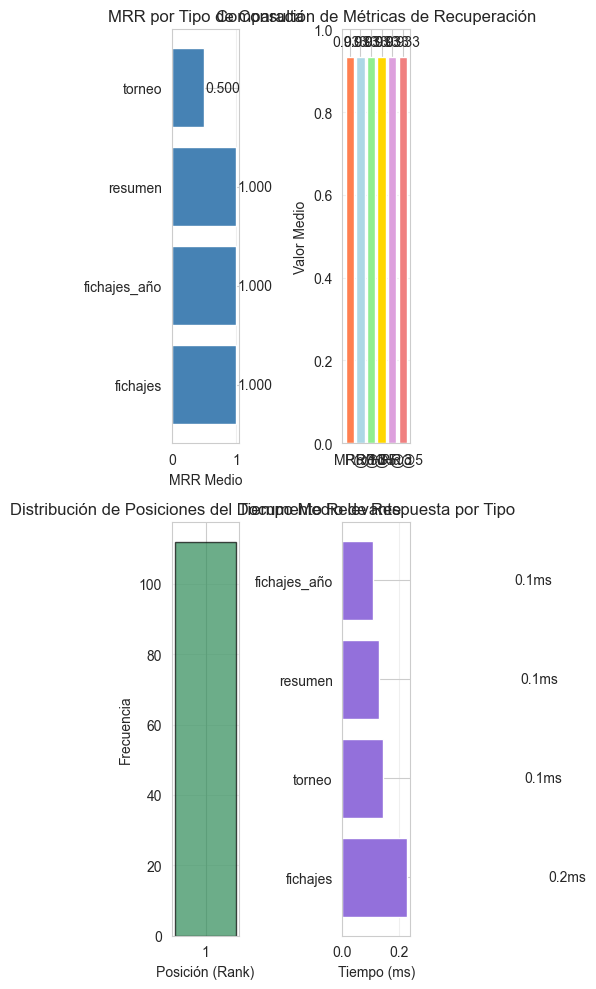


✅ Visualizaciones guardadas en: c:\dev-nlp\MTPLN\proyecto-liquipedia\EDA_results\Resultados_Evaluacion.png


In [38]:
# Visualizaciones de resultados
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. MRR por tipo de consulta
type_mrr = results_df.groupby('type')['RR'].mean().sort_values(ascending=False)
axes[0, 0].barh(type_mrr.index, type_mrr.values, color='steelblue')
axes[0, 0].set_xlabel('MRR Medio')
axes[0, 0].set_title('MRR por Tipo de Consulta')
axes[0, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(type_mrr.values):
    axes[0, 0].text(v + 0.02, i, f'{v:.3f}', va='center')

# 2. Distribución de métricas
metrics_means = {
    'MRR': results_df['RR'].mean(),
    'P@1': results_df['P@1'].mean(),
    'P@3': results_df['P@3'].mean(),
    'P@5': results_df['P@5'].mean(),
    'HR@3': results_df['HR@3'].mean(),
    'HR@5': results_df['HR@5'].mean()
}
axes[0, 1].bar(metrics_means.keys(), metrics_means.values(), color=['coral', 'lightblue', 'lightgreen', 'gold', 'plum', 'lightcoral'])
axes[0, 1].set_ylabel('Valor Medio')
axes[0, 1].set_title('Comparación de Métricas de Recuperación')
axes[0, 1].set_ylim([0, 1.0])
axes[0, 1].grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(metrics_means.items()):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

# 3. Distribución de ranks
rank_counts = results_df[results_df['rank'] != 'N/A']['rank'].value_counts().sort_index()
axes[1, 0].bar(rank_counts.index.astype(str), rank_counts.values, color='seagreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Posición (Rank)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Posiciones del Documento Relevante')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Tiempo de respuesta por tipo de consulta
type_time = results_df.groupby('type')['response_time'].mean().sort_values(ascending=False) * 1000
axes[1, 1].barh(type_time.index, type_time.values, color='mediumpurple')
axes[1, 1].set_xlabel('Tiempo (ms)')
axes[1, 1].set_title('Tiempo Medio de Respuesta por Tipo')
axes[1, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(type_time.values):
    axes[1, 1].text(v + 0.5, i, f'{v:.1f}ms', va='center')

plt.tight_layout()

# Crear carpeta de resultados si no existe
results_dir = project_root / 'EDA_results'
results_dir.mkdir(exist_ok=True)

plt.savefig(str(results_dir / 'Resultados_Evaluacion.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Visualizaciones guardadas en: {results_dir / 'Resultados_Evaluacion.png'}")

In [39]:
# Crear carpeta de resultados si no existe
results_dir = project_root / 'EDA_results'
results_dir.mkdir(exist_ok=True)

# Guardar resultados en archivos CSV
output_file = results_dir / 'evaluation_results.csv'
results_df.to_csv(output_file, index=False, encoding='utf-8')
print(f"💾 Resultados guardados en: {output_file}")

# Exportar métricas agregadas para LaTeX
summary_stats = {
    'Total_Queries': len(results_df),
    'MRR': results_df['RR'].mean(),
    'P@1': results_df['P@1'].mean(),
    'P@3': results_df['P@3'].mean(),
    'P@5': results_df['P@5'].mean(),
    'R@3': results_df['R@3'].mean(),
    'R@5': results_df['R@5'].mean(),
    'HR@3': results_df['HR@3'].mean(),
    'HR@5': results_df['HR@5'].mean(),
    'Avg_Response_Time_ms': results_df['response_time'].mean() * 1000,
    'Throughput_queries_per_sec': 1 / results_df['response_time'].mean(),
    'Perfect_Queries_Pct': (len(results_df[results_df['rank'] == 1]) / len(results_df)) * 100,
    'Top3_Queries_Pct': (len(results_df[results_df['HR@3'] == 1]) / len(results_df)) * 100,
    'Failed_Queries_Pct': (len(results_df[results_df['rank'] == 'N/A']) / len(results_df)) * 100
}

summary_df = pd.DataFrame([summary_stats])
summary_file = results_dir / 'evaluation_summary.csv'
summary_df.to_csv(summary_file, index=False, encoding='utf-8')
print(f"💾 Resumen estadístico guardado en: {summary_file}")

# Tabla resumen por tipo de consulta
type_summary = results_df.groupby('type').agg({
    'RR': 'mean',
    'P@1': 'mean',
    'P@3': 'mean',
    'HR@3': 'mean',
    'response_time': 'mean'
}).round(4)
type_summary['count'] = results_df.groupby('type').size()
type_summary_file = results_dir / 'evaluation_by_type.csv'
type_summary.to_csv(type_summary_file, encoding='utf-8')
print(f"💾 Resultados por tipo guardados en: {type_summary_file}")

print(f"\n✅ Todos los archivos CSV generados correctamente")
print(f"📁 Archivos disponibles en {results_dir}:")
print(f"   - evaluation_results.csv: {len(results_df)} filas (resultados detallados)")
print(f"   - evaluation_summary.csv: Métricas agregadas globales")
print(f"   - evaluation_by_type.csv: Métricas por tipo de consulta")

💾 Resultados guardados en: c:\dev-nlp\MTPLN\proyecto-liquipedia\EDA_results\evaluation_results.csv
💾 Resumen estadístico guardado en: c:\dev-nlp\MTPLN\proyecto-liquipedia\EDA_results\evaluation_summary.csv
💾 Resultados por tipo guardados en: c:\dev-nlp\MTPLN\proyecto-liquipedia\EDA_results\evaluation_by_type.csv

✅ Todos los archivos CSV generados correctamente
📁 Archivos disponibles en c:\dev-nlp\MTPLN\proyecto-liquipedia\EDA_results:
   - evaluation_results.csv: 120 filas (resultados detallados)
   - evaluation_summary.csv: Métricas agregadas globales
   - evaluation_by_type.csv: Métricas por tipo de consulta


## 11. Conclusiones y Recomendaciones para la Memoria

### ✅ Ventajas del Sistema de Templates

1. **Escalabilidad**: Fácil generar cientos de consultas cambiando parámetros
2. **Reproducibilidad**: Sistema determinista y documentado
3. **Cobertura**: Evalúa múltiples equipos del corpus automáticamente
4. **Tipos variados**: 5 tipos de consultas × N templates × M equipos

### 📊 Métricas a Reportar en `resultados.tex`

#### Métricas Principales:
- **MRR (Mean Reciprocal Rank)**: Posición promedio del primer documento relevante
- **Precision@k**: Proporción de documentos relevantes en top-k
- **Hit Rate@k**: Al menos un documento relevante en top-k

#### Análisis por Tipo:
- Comparar rendimiento según tipo de consulta
- Identificar fortalezas y debilidades del sistema
- Discutir por qué ciertos tipos funcionan mejor

### 📁 Archivos Generados para LaTeX

```
evaluation_results.csv       → Resultados por consulta (para tablas detalladas)
evaluation_summary.csv        → Métricas globales (para tabla resumen)
evaluation_by_type.csv        → Métricas por tipo (para comparaciones)
evaluation_examples.csv       → Ejemplos seleccionados (para análisis cualitativo)
Resultados_Evaluacion.png    → 4 gráficas (para figura compuesta)
```

### 💡 Análisis Cualitativo Recomendado

1. **Consultas de información general**: Analizar si el sistema identifica correctamente el equipo
2. **Consultas temporales**: Evaluar capacidad de filtrar por fechas
3. **Consultas sobre fichajes**: Medir precisión en identificar movimientos de jugadores
4. **Errores sistemáticos**: Identificar patrones en consultas fallidas

### 🔍 Posibles Extensiones

- Aumentar número de equipos (de 8 a 20+)
- Añadir más templates por tipo
- Incluir consultas multi-equipo
- Evaluar con BERTScore (generación)

## 10. Análisis Cualitativo: Ejemplos de Respuestas del Sistema

Para entender mejor el comportamiento del sistema, veamos ejemplos concretos de consultas con las respuestas que devuelve el modelo de recuperación.

In [40]:
# Función para mostrar ejemplos de respuestas del sistema
def show_query_examples(query, relevant, max_results=3, max_text_length=200):
    """
    Muestra un ejemplo de consulta con los documentos recuperados y sus textos
    """
    print("=" * 100)
    print(f"🔍 CONSULTA: {query}")
    print(f"📌 RESPUESTA ESPERADA: {relevant}")
    print("-" * 100)
    
    # Realizar búsqueda
    retrieved = store.search(query, top_k=5)
    
    if not retrieved:
        print("❌ No se encontraron resultados")
        return
    
    # Mostrar resultados
    for idx, result in enumerate(retrieved[:max_results], 1):
        doc_name = result.get('name', 'Unknown')
        doc_text = result.get('text', '')[:max_text_length]
        
        # Marcar si es el documento correcto
        is_correct = doc_name.strip().lower() == relevant.strip().lower()
        marker = "✅" if is_correct else "  "
        
        print(f"\n{marker} [{idx}] {doc_name}")
        print(f"   Texto: {doc_text}...")
        
    print("=" * 100)
    print()

# Seleccionar ejemplos representativos de diferentes escenarios
print("📊 EJEMPLOS DE RESPUESTAS DEL SISTEMA\n")

# 1. Ejemplos de consultas exitosas (rank = 1)
perfect_examples = results_df[results_df['rank'] == 1]
if len(perfect_examples) > 0:
    perfect_examples = perfect_examples.sample(min(3, len(perfect_examples)))
    print("✅ EJEMPLOS DE CONSULTAS EXITOSAS (rank=1)\n")
    for _, row in perfect_examples.iterrows():
        show_query_examples(row['query'], row['relevant'])

# 2. Ejemplos de consultas con rank > 1 (filtrar primero los numéricos)
suboptimal_mask = (results_df['rank'] != 'N/A') & (pd.to_numeric(results_df['rank'], errors='coerce') > 1)
suboptimal_examples = results_df[suboptimal_mask]
if len(suboptimal_examples) > 0:
    suboptimal_examples = suboptimal_examples.sample(min(3, len(suboptimal_examples)))
    print("\n⚠️  EJEMPLOS DE CONSULTAS SUBÓPTIMAS (rank>1)\n")
    for _, row in suboptimal_examples.iterrows():
        show_query_examples(row['query'], row['relevant'])

# 3. Ejemplos de consultas fallidas
failed_examples = results_df[results_df['rank'] == 'N/A']
if len(failed_examples) > 0:
    failed_examples = failed_examples.sample(min(3, len(failed_examples)))
    print("\n❌ EJEMPLOS DE CONSULTAS FALLIDAS (no encontrado en top-5)\n")
    for _, row in failed_examples.iterrows():
        show_query_examples(row['query'], row['relevant'])

📊 EJEMPLOS DE RESPUESTAS DEL SISTEMA

✅ EJEMPLOS DE CONSULTAS EXITOSAS (rank=1)

🔍 CONSULTA: ¿Qué jugadores fichó 3DMAX en 2023?
📌 RESPUESTA ESPERADA: 3DMAX
----------------------------------------------------------------------------------------------------

✅ [1] 3DMAX
   Texto: 3DMAX. 3DMAX es una organización francesa de deportes electrónicos fundada en 2009 que en su versión original albergó varias listas de Counter-Strike: Global Offensive, Counter-Strike: Source y Counte...

   [2] ATOX Esports
   Texto: ATOX Esports. ATOX Esports es una organización de deportes electrónicos de Mongolia fundada en junio de 2023....

   [3] BESTIA
   Texto: BESTIA. BESTIA es una organización argentina de deportes electrónicos profesionales fundada el 14 de febrero de 2023 por un jugador de póquer y rapero argentino Alejandro "Papo MC" Lococo....

🔍 CONSULTA: ¿Qué jugadores fichó 9INE en 2024?
📌 RESPUESTA ESPERADA: 9INE
-------------------------------------------------------------------------------

In [41]:
# Análisis detallado de casos específicos por tipo de consulta
print("\n" + "=" * 100)
print("📋 ANÁLISIS DETALLADO POR TIPO DE CONSULTA")
print("=" * 100)

# Obtener tipos de consulta disponibles dinámicamente
available_types = results_df['type'].unique()

for query_type in available_types:
    type_queries = results_df[results_df['type'] == query_type]
    if len(type_queries) == 0:
        continue
    
    # Tomar un ejemplo representativo de cada tipo
    example = type_queries.sample(1).iloc[0]
    
    print(f"\n📌 TIPO: {query_type.upper()}")
    print(f"   Consulta: {example['query']}")
    print(f"   Esperado: {example['relevant']}")
    print(f"   Resultado: Rank {example['rank']} | MRR: {example['RR']:.3f} | P@3: {example['P@3']:.3f}")
    print()
    
    # Mostrar top-3 resultados
    retrieved = store.search(example['query'], top_k=3)
    for idx, result in enumerate(retrieved, 1):
        doc_name = result.get('name', 'Unknown')
        doc_text = result.get('text', '')[:150]
        is_correct = doc_name.strip().lower() == example['relevant'].strip().lower()
        marker = "✅" if is_correct else "❌"
        
        print(f"   {marker} [{idx}] {doc_name}")
        print(f"       └─ {doc_text}...")
    print()

print("=" * 100)


📋 ANÁLISIS DETALLADO POR TIPO DE CONSULTA

📌 TIPO: RESUMEN
   Consulta: ¿Qué es 3DMAX?
   Esperado: 3DMAX
   Resultado: Rank 1 | MRR: 1.000 | P@3: 1.000

   ✅ [1] 3DMAX
       └─ 3DMAX. 3DMAX es una organización francesa de deportes electrónicos fundada en 2009 que en su versión original albergó varias listas de Counter-Strike:...
   ❌ [2] M80
       └─ M80. M80 es una organización estadounidense de deportes electrónicos....
   ❌ [3] Metizport
       └─ Metizport. Metizport es una organización noruega de deportes electrónicos....


📌 TIPO: FICHAJES
   Consulta: ¿Cuáles son los fichajes más recientes de Aurora Gaming?
   Esperado: Aurora Gaming
   Resultado: Rank 1 | MRR: 1.000 | P@3: 1.000

   ✅ [1] Aurora Gaming
       └─ Aurora Gaming. Aurora Gaming es una organización serbia de deportes electrónicos profesionales....
   ❌ [2] Complexity
       └─ Complexity. Complexity (abreviado como COL y anteriormente estilizado como Complexity Gaming y compLexity Gaming) es una organización est

In [42]:
# Crear carpeta de resultados si no existe
results_dir = project_root / 'EDA_results'
results_dir.mkdir(exist_ok=True)

# Crear tabla resumen con ejemplos seleccionados para la memoria
print("\n📊 TABLA RESUMEN: EJEMPLOS SELECCIONADOS PARA LA MEMORIA")
print("=" * 100)

# Seleccionar ejemplos variados
examples_for_paper = []

# 1 perfecto + 1 subóptimo de cada tipo si es posible
for query_type in results_df['type'].unique():
    type_df = results_df[results_df['type'] == query_type]
    
    # 1 perfecto
    perfect = type_df[type_df['rank'] == 1]
    if len(perfect) > 0:
        examples_for_paper.append(perfect.sample(1))
    
    # 1 subóptimo (filtrar correctamente los valores numéricos)
    suboptimal_mask = (type_df['rank'] != 'N/A') & (pd.to_numeric(type_df['rank'], errors='coerce') > 1)
    suboptimal = type_df[suboptimal_mask]
    if len(suboptimal) > 0:
        examples_for_paper.append(suboptimal.sample(1))

# Combinar ejemplos
if examples_for_paper:
    examples_df = pd.concat(examples_for_paper)
    
    # Mostrar tabla compacta
    display_df = examples_df[['type', 'query', 'relevant', 'rank', 'RR', 'P@3', 'HR@3']].copy()
    display_df['query'] = display_df['query'].str[:50] + '...'
    display_df = display_df.sort_values(['type', 'rank'])
    
    print(display_df.to_string(index=False))
    
    # Guardar ejemplos seleccionados
    examples_file = results_dir / 'evaluation_examples.csv'
    examples_df.to_csv(examples_file, index=False, encoding='utf-8')
    print(f"\n💾 Ejemplos seleccionados guardados en: {examples_file}")
else:
    print("No hay suficientes ejemplos para mostrar")

print("\n✅ Estos ejemplos pueden usarse en la sección de resultados de la memoria para"
      "\n   ilustrar el comportamiento del sistema con casos concretos.")


📊 TABLA RESUMEN: EJEMPLOS SELECCIONADOS PARA LA MEMORIA
        type                                  query relevant rank  RR  P@3  HR@3
    fichajes        ¿Qué fichajes hizo Astralis?... Astralis    1 1.0  1.0   1.0
fichajes_año ¿Qué jugadores fichó Apeks en 2025?...    Apeks    1 1.0  1.0   1.0
     resumen               ¿De qué país es 9INE?...     9INE    1 1.0  1.0   1.0
      torneo    Cual es el proximo torneo de 500...      500    1 1.0  1.0   1.0

💾 Ejemplos seleccionados guardados en: c:\dev-nlp\MTPLN\proyecto-liquipedia\EDA_results\evaluation_examples.csv

✅ Estos ejemplos pueden usarse en la sección de resultados de la memoria para
   ilustrar el comportamiento del sistema con casos concretos.
